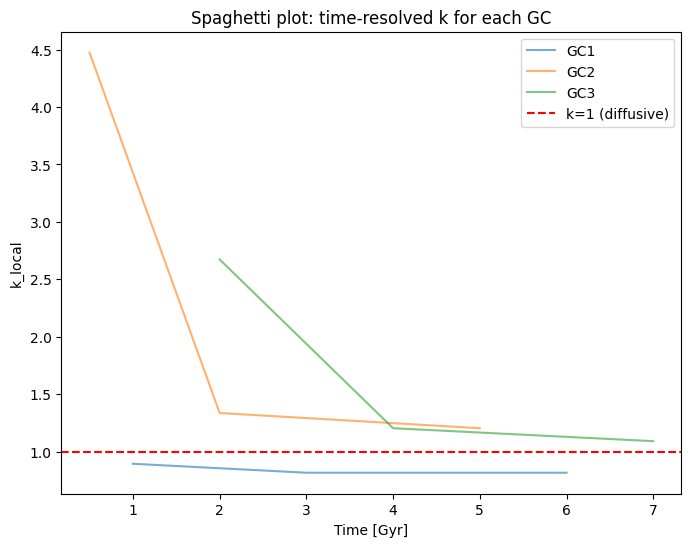

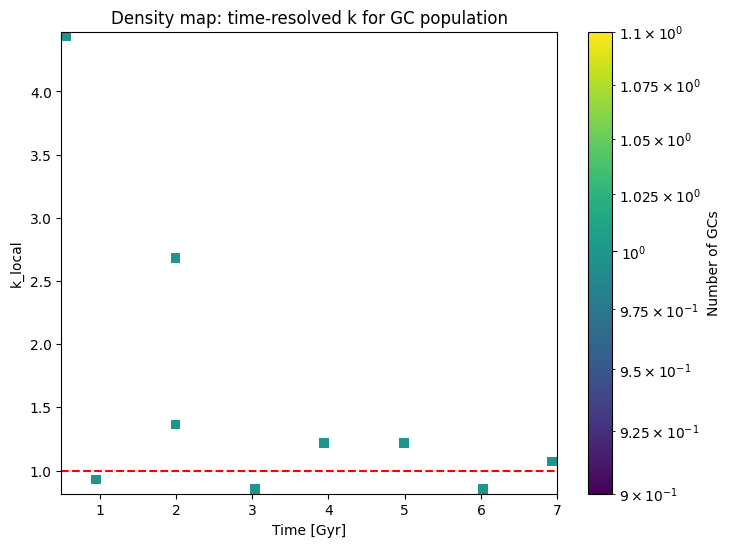

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


# -------------------------
# Helper function: compute k_local over intervals
# -------------------------
def compute_k(gc_snapshots):
    """
    gc_snapshots: list of (t, x, y, z)
    returns: times, k_local values
    """
    times = []
    k_vals = []

    for i in range(len(gc_snapshots) - 1):
        t0, x0, y0, z0 = gc_snapshots[i]
        t1, x1, y1, z1 = gc_snapshots[i + 1]
        dt = t1 - t0

        # net displacement
        dr_net = np.sqrt((x1 - x0) ** 2 + (y1 - y0) ** 2 + (z1 - z0) ** 2)

        # path displacement (single step = net for this interval)
        dr_path = dr_net  # if you have substeps, sum them

        # local k
        if dr_net > 0:
            k_local = dr_path / (dr_net**2)
        else:
            k_local = 0

        times.append(t1)
        k_vals.append(k_local)

    return np.array(times), np.array(k_vals)


# -------------------------
# Example: population of GCs
# -------------------------
gc_positions = {
    "GC1": [(0, 0, 0, 0), (1, 1, 0.5, 0), (3, 2, 1, 0.5), (6, 3, 1.5, 1)],
    "GC2": [(0, 0, 0, 0), (0.5, 0.2, 0.1, 0), (2, 0.8, 0.5, 0.2), (5, 1.5, 0.9, 0.4)],
    "GC3": [(1, 0, 0, 0), (2, 0.3, 0.2, 0.1), (4, 1.0, 0.6, 0.3), (7, 1.8, 1.0, 0.5)],
}

# Compute k(t) for all GCs
all_times = []
all_k = []

plt.figure(figsize=(8, 6))

for gcid, snapshots in gc_positions.items():
    times, k_vals = compute_k(snapshots)
    all_times.extend(times)
    all_k.extend(k_vals)

    # Spaghetti plot
    plt.plot(times, k_vals, alpha=0.6, label=gcid)

plt.axhline(1, color="red", linestyle="--", label="k=1 (diffusive)")
plt.xlabel("Time [Gyr]")
plt.ylabel("k_local")
plt.title("Spaghetti plot: time-resolved k for each GC")
plt.legend()
plt.show()

# -------------------------
# Density map approach
# -------------------------
plt.figure(figsize=(8, 6))

# 2D histogram
plt.hist2d(all_times, all_k, bins=[50, 50], norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Number of GCs")
plt.axhline(1, color="red", linestyle="--", label="k=1 (diffusive)")
plt.xlabel("Time [Gyr]")
plt.ylabel("k_local")
plt.title("Density map: time-resolved k for GC population")
plt.show()


# Calculate k in a 2 Gyr box window for each GC group. Maybe do accretion events and split in-situ into age groups

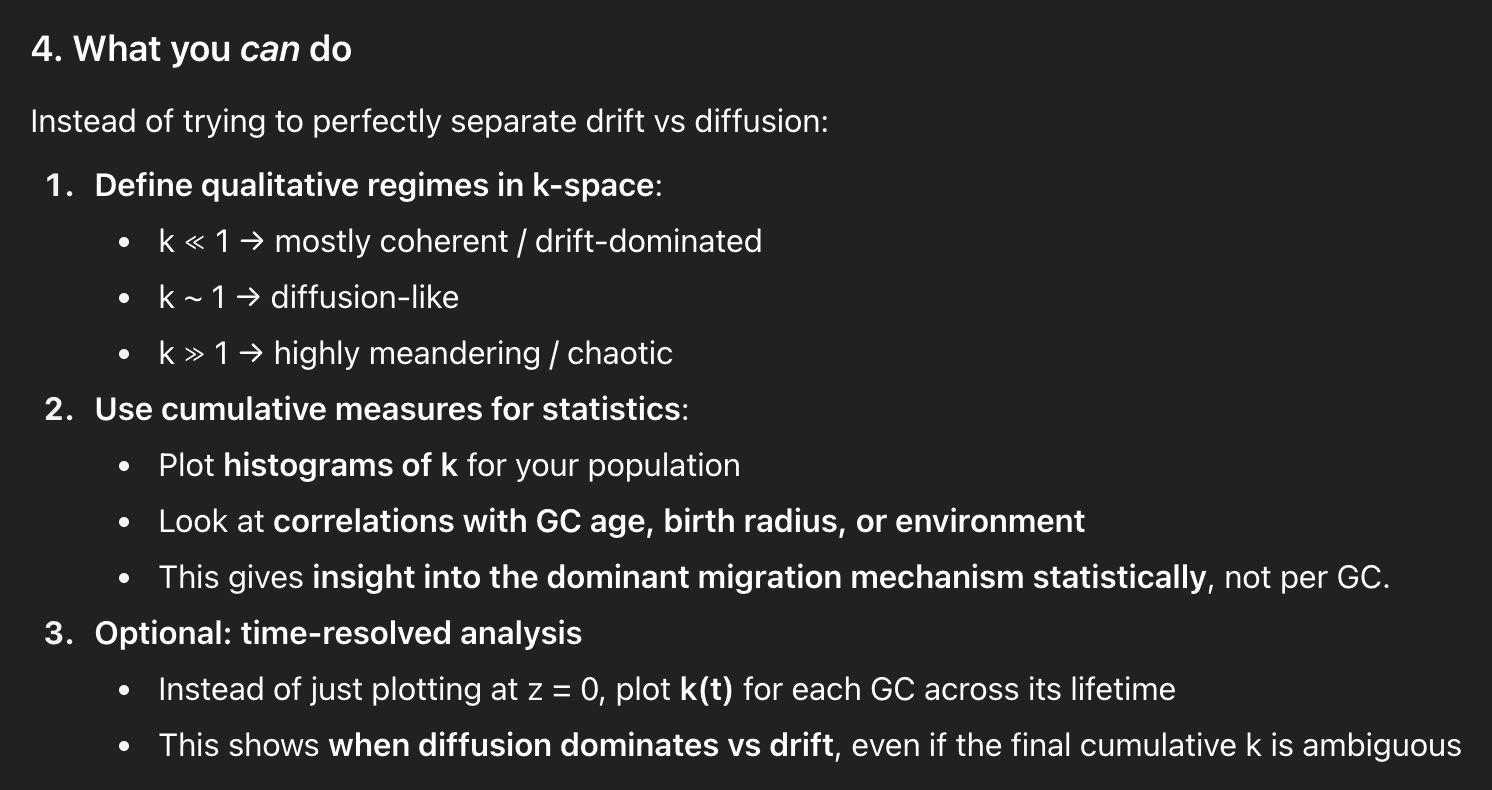

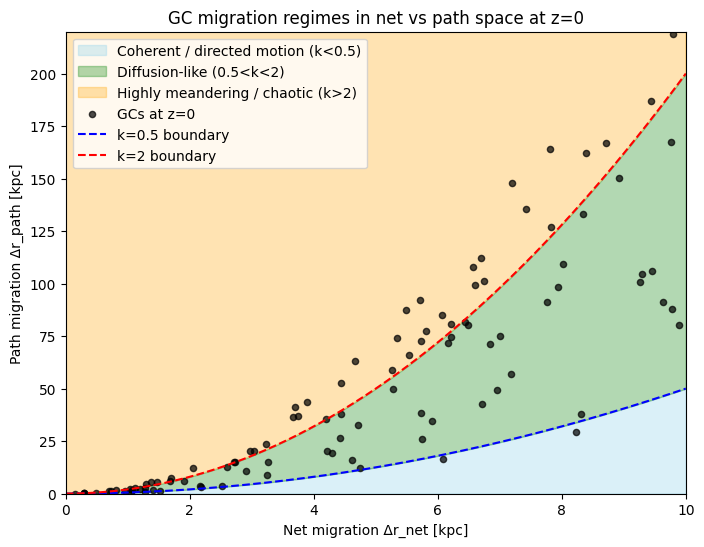

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Mock net migration values (kpc)
net = np.linspace(0, 10, 500)

# Define k boundaries
k_coherent = 0.5
k_diff_high = 2.0

# Corresponding path migration parabolas
path_coherent = k_coherent * net**2
path_diff_high = k_diff_high * net**2

# Mock GC population (for demonstration)
np.random.seed(0)
n_GC = 100
delta_r_net = np.random.uniform(0.1, 10, n_GC)
delta_r_path = delta_r_net**2 * np.random.uniform(0.4, 3.0, n_GC)

# -------------------------
# Plotting
# -------------------------
plt.figure(figsize=(8, 6))

# Shade regions
plt.fill_between(
    net, 0, path_coherent, color="skyblue", alpha=0.3, label="Coherent / directed motion (k<0.5)"
)
plt.fill_between(
    net, path_coherent, path_diff_high, color="green", alpha=0.3, label="Diffusion-like (0.5<k<2)"
)
plt.fill_between(
    net,
    path_diff_high,
    np.max(path_diff_high) * 1.5,
    color="orange",
    alpha=0.3,
    label="Highly meandering / chaotic (k>2)",
)

# Plot GC points
plt.scatter(delta_r_net, delta_r_path, c="black", s=20, alpha=0.7, label="GCs at z=0")

# Plot k boundary curves
plt.plot(net, path_coherent, color="blue", linestyle="--", label="k=0.5 boundary")
plt.plot(net, path_diff_high, color="red", linestyle="--", label="k=2 boundary")

plt.xlabel("Net migration Δr_net [kpc]")
plt.ylabel("Path migration Δr_path [kpc]")
plt.title("GC migration regimes in net vs path space at z=0")
plt.legend()
plt.xlim(0, 10)
plt.ylim(0, np.max(path_diff_high) * 1.1)
plt.show()


In [4]:
# can colour by age and can also colour by average radius (average radius since accretion for accreted GCs)

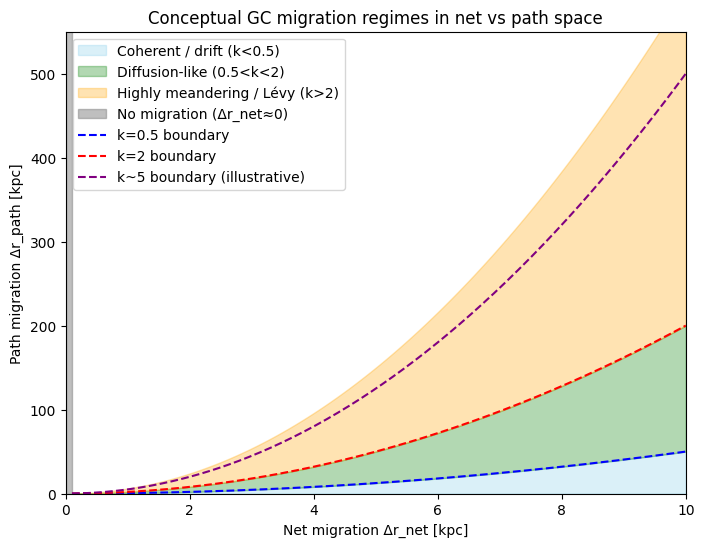

In [ ]:
# Net migration axis
net = np.linspace(0.1, 10, 500)  # start >0 to avoid k blowup

# Define example k boundaries
k_coherent = 0.5
k_diff_high = 2.0
k_chaotic = 5.0  # illustrative high k for Lévy flights

# Corresponding path curves
path_coherent = k_coherent * net**2
path_diff_high = k_diff_high * net**2
path_chaotic = k_chaotic * net**2

# Shade regions
plt.figure(figsize=(8, 6))
plt.fill_between(net, 0, path_coherent, color="skyblue", alpha=0.3, label="Coherent / drift (k<0.5)")
plt.fill_between(
    net, path_coherent, path_diff_high, color="green", alpha=0.3, label="Diffusion-like (0.5<k<2)"
)
plt.fill_between(
    net, path_diff_high, path_chaotic * 1.2, color="orange", alpha=0.3, label="Highly meandering / Lévy (k>2)"
)
plt.fill_betweenx(
    np.linspace(0, np.max(path_chaotic * 1.2), 50),
    0,
    0.1,
    color="gray",
    alpha=0.5,
    label="No migration (Δr_net≈0)",
)

# Plot boundary curves
plt.plot(net, path_coherent, "b--", label="k=0.5 boundary")
plt.plot(net, path_diff_high, "r--", label="k=2 boundary")
plt.plot(net, path_chaotic, "purple", linestyle="--", label="k~5 boundary (illustrative)")

# Labels
plt.xlabel("Net migration Δr_net [kpc]")
plt.ylabel("Path migration Δr_path [kpc]")
plt.title("Conceptual GC migration regimes in net vs path space")
plt.legend()
plt.ylim(0, np.max(path_chaotic * 1.1))
plt.xlim(0, np.max(net))
plt.show()
